In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from IPython.display import clear_output

# Load datasets
df_gestalt = pd.read_csv("stimuli_gestalt.csv")
df_tips = pd.read_csv("tips.csv")

Gestalt dataset shape: (284, 8)
Panels present: <StringArray>
['proximity', 'similarity', 'enclosure', 'continuity', 'closure',
 'connection']
Length: 6, dtype: str


## 1. Render All 6 Gestalt Panels ($2 \times 3$ Grid)

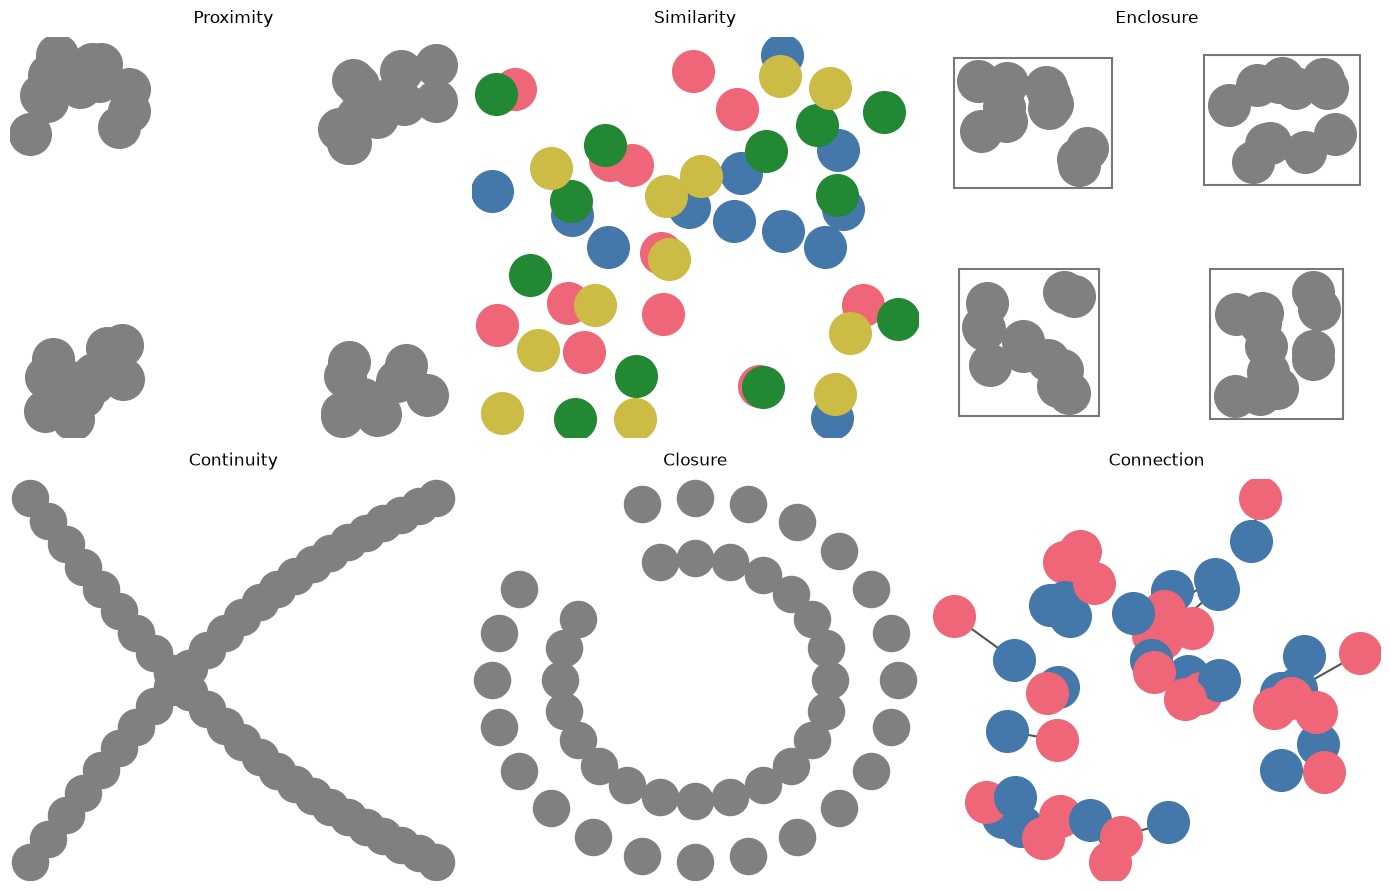

In [3]:
# List of principles in layout order
panels = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, panel_name in enumerate(panels):
    ax = axes[idx]
    panel_df = df_gestalt[df_gestalt["panel"] == panel_name]
    
    # 1. Draw connecting lines for the 'connection' principle
    if panel_name == "connection":
        # Group by connector ID to pair items
        for conn_id, group_data in panel_df.groupby("connector"):
            if len(group_data) == 2:
                x_vals = group_data["x"].values
                y_vals = group_data["y"].values
                ax.plot(x_vals, y_vals, color="#555555", linewidth=1.5, zorder=1)
                
    # 2. Draw scatter points for all panels
    for _, row in panel_df.iterrows():
        ax.scatter(
            row["x"], 
            row["y"], 
            color=row["colour"], 
            s=row["size"] * 15, 
            zorder=2
        )
        
    # 3. Add explicit boundaries for the 'enclosure' principle
    if panel_name == "enclosure":
        # Draw 4 grey rectangle boundaries around the 4 distinct clumps
        for group_id, group_data in panel_df.groupby("group"):
            x_min, x_max = group_data["x"].min(), group_data["x"].max()
            y_min, y_max = group_data["y"].min(), group_data["y"].max()
            
            # Add padding around items
            pad = 0.5
            rect = patches.Rectangle(
                (x_min - pad, y_min - pad),
                (x_max - x_min + 2 * pad),
                (y_max - y_min + 2 * pad),
                linewidth=1.5,
                edgecolor="#777777",
                facecolor="none",
                zorder=1
            )
            ax.add_patch(rect)

    # Styling requirements: Clean layout with no axes, ticks, or spines
    ax.set_title(panel_name.capitalize(), fontsize=12, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

## 2. Human Perception Test Results

In [4]:

# True group counts defined by the task specifications
TRUE_GROUPS = {
    "proximity": 4,
    "similarity": 4,
    "enclosure": 4,
    "continuity": 2,
    "closure": 2,
    "connection": 24
}

panels = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]
survey_results = []

# --- Step 2: Interactive Panel-by-Panel Experiment ---
for panel_name in panels:
    # 1. Clear previous output completely before showing the new panel
    clear_output(wait=True)
    
    # 2. Setup Object-Oriented plot figure
    fig, ax = plt.subplots(figsize=(6, 5))
    panel_df = df_gestalt[df_gestalt["panel"] == panel_name]
    
    # Draw connectors if connection panel
    if panel_name == "connection":
        for conn_id, group_data in panel_df.groupby("connector"):
            if len(group_data) == 2:
                ax.plot(group_data["x"].values, group_data["y"].values, color="#555555", linewidth=1.5, zorder=1)
                
    # Draw scatter points
    for _, row in panel_df.iterrows():
        ax.scatter(row["x"], row["y"], color=row["colour"], s=row["size"] * 15, zorder=2)
        
    # Draw enclosure rectangles if enclosure panel
    if panel_name == "enclosure":
        for group_id, group_data in panel_df.groupby("group"):
            x_min, x_max = group_data["x"].min(), group_data["x"].max()
            y_min, y_max = group_data["y"].min(), group_data["y"].max()
            pad = 0.5
            rect = patches.Rectangle(
                (x_min - pad, y_min - pad),
                (x_max - x_min + 2 * pad),
                (y_max - y_min + 2 * pad),
                linewidth=1.5,
                edgecolor="#777777",
                facecolor="none",
                zorder=1
            )
            ax.add_patch(rect)

    # Style panel cleanly
    ax.set_title(f"Panel: {panel_name.capitalize()}", fontsize=12, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

    plt.tight_layout()
    plt.show()

    # 3. Prompt user for input
    response = input(f"Looking at panel '{panel_name}', how many groups do you see? ")
    
    try:
        perceived = int(response.strip())
    except ValueError:
        perceived = 0

    true_count = TRUE_GROUPS[panel_name]
    match = "Yes" if perceived == true_count else "No"
    
    survey_results.append({
        "panel": panel_name,
        "principle": panel_name.capitalize(),
        "true_groups": true_count,
        "perceived_groups": perceived,
        "match": match
    })

# Clear notebook display after completing all panels
clear_output(wait=True)

# 4. Display final summary table as required by Step 2
df_results = pd.DataFrame(survey_results)
print("--- Experiment Results ---")
df_results

--- Experiment Results ---


,panel,principle,true_groups,perceived_groups,match
0,proximity,Proximity,4,4,Yes
1,similarity,Similarity,4,4,Yes
2,enclosure,Enclosure,4,4,Yes
3,continuity,Continuity,2,2,Yes
4,closure,Closure,2,2,Yes
5,connection,Connection,24,24,Yes


## 3. Principle Rivalry (Connection vs. Proximity & Similarity)

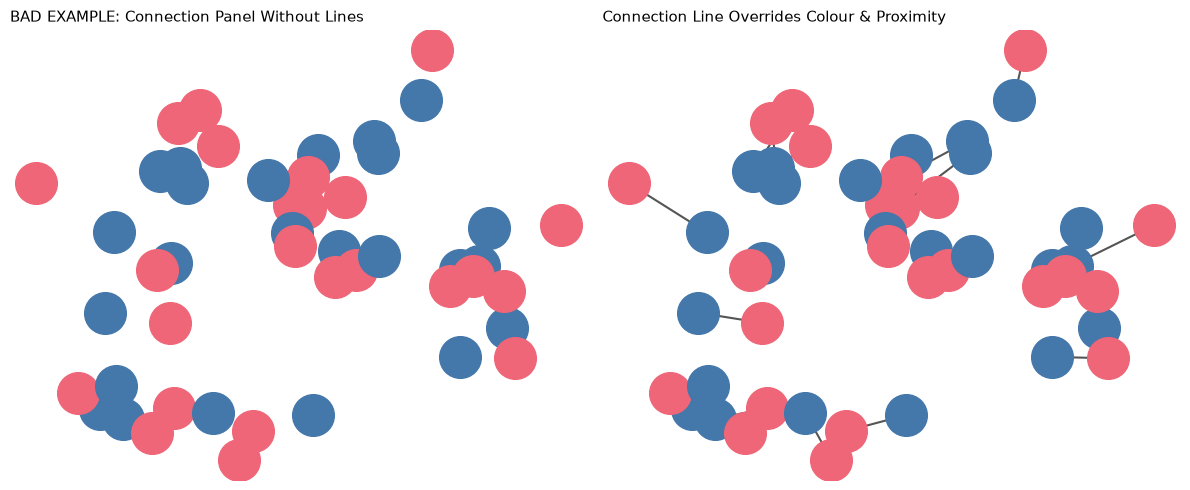

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

conn_df = df_gestalt[df_gestalt["panel"] == "connection"]

# Panel A: Without lines (Proximity & Similarity dominate)
for _, row in conn_df.iterrows():
    ax1.scatter(row["x"], row["y"], color=row["colour"], s=row["size"] * 15)
ax1.set_title("BAD EXAMPLE: Connection Panel Without Lines", fontsize=11, loc="left")

# Panel B: With lines (Connection beats Proximity & Similarity)
for conn_id, group_data in conn_df.groupby("connector"):
    if len(group_data) == 2:
        ax2.plot(group_data["x"].values, group_data["y"].values, color="#555555", linewidth=1.5, zorder=1)

for _, row in conn_df.iterrows():
    ax2.scatter(row["x"], row["y"], color=row["colour"], s=row["size"] * 15, zorder=2)
ax2.set_title("Connection Line Overrides Colour & Proximity", fontsize=11, loc="left")

# Format both axes cleanly
for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

## Principle Rivalry Outcome
When the connecting lines are removed, the reader groups items by spatial proximity and color similarity. However, as soon as connecting lines are added, connection wins over both proximity and similarity.The reader instantly perceives 24 distinct paired relationships, ignoring the fact that paired dots are separated by distance and have different colors.

## 4. Proximity Demonstration on Real Data

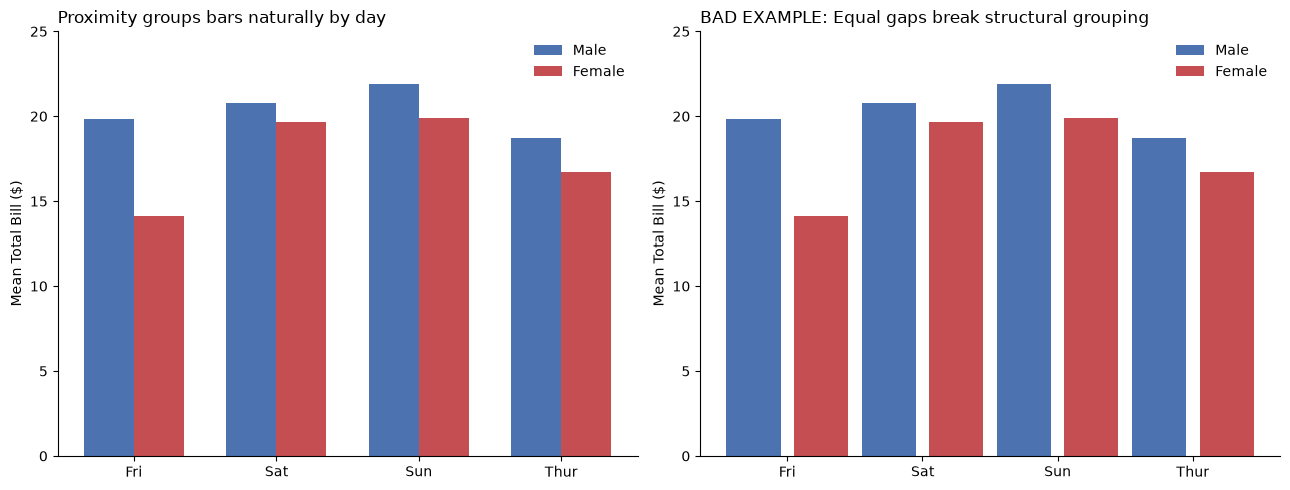

In [6]:
# Calculate average total bill across Day and Sex
grouped_tips = df_tips.groupby(["day", "sex"], observed=False)["total_bill"].mean().unstack()
days = grouped_tips.index
x = np.arange(len(days))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Correct Proximity: Narrow gap within group, wide gap between days
width_narrow = 0.35
ax1.bar(x - width_narrow/2, grouped_tips["Male"], width=width_narrow, label="Male", color="#4c72b0")
ax1.bar(x + width_narrow/2, grouped_tips["Female"], width=width_narrow, label="Female", color="#c44e52")
ax1.set_title("Proximity groups bars naturally by day", loc="left")
ax1.set_xticks(x)
ax1.set_xticklabels(days)
ax1.set_ylabel("Mean Total Bill ($)")
ax1.set_ylim(0, 25)
ax1.legend(frameon=False)
for side in ("top", "right"):
    ax1.spines[side].set_visible(False)

# 2. Broken Proximity: Equal gaps destroy day grouping
x_male = np.array([0.0, 1.0, 2.0, 3.0])
x_female = np.array([0.5, 1.5, 2.5, 3.5])

ax2.bar(x_male, grouped_tips["Male"], width=0.4, label="Male", color="#4c72b0")
ax2.bar(x_female, grouped_tips["Female"], width=0.4, label="Female", color="#c44e52")
ax2.set_title("BAD EXAMPLE: Equal gaps break structural grouping", loc="left")
ax2.set_xticks([0.25, 1.25, 2.25, 3.25])
ax2.set_xticklabels(days)
ax2.set_ylabel("Mean Total Bill ($)")
ax2.set_ylim(0, 25)
ax2.legend(frameon=False)
for side in ("top", "right"):
    ax2.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

## Proximity Loss in Bar Charts
In the second version with equal spacing, the reader loses the immediate visual distinction between intra-day comparisons and inter-day comparisons. Because the spacing between Male and Female bars is identical to the spacing between Thur and Fri, the visual hierarchy collapses, forcing the reader to read text labels manually to figure out which bar belongs to which day.

## 5. Gestalt Principles in Standard Charts
<h3> Proximity: </h3> 
Used in grouped bar charts, where bars belonging to the same category are placed closer together than bars from different categories.
<h3> Similarity: </h3> 
Used in color legends, where data series share the same hue or shape marker across a plot
<h3> Enclosure: </h3>
Used in shaded background bands (e.g., highlighting recession periods) or annotated bounding boxes around outliers.
<h3> Closure:</h3> 
Used in dashed or dotted line charts, where the brain perceives a continuous line despite physical gaps between dashes.
<h3> Continuity: </h3> 
Used in smooth trend lines or streamgraphs, helping the eye track individual series through intersections.
<h3> Connection: </h3>
Used in line charts and node-link network graphs, where explicit lines connect data points to show relationship or sequence

## 6. Direct Labeling vs. Legends in Terms of Load
<h3> Principle Used: </h3>
Direct labeling relies on Proximity (placing the label right next to the data line/bar).   
<h3>Cognitive Load Explanation:</h3> 
A separate color legend increases extraneous cognitive load. It forces the reader to hold a color hue in working memory (which holds only $4 \pm 1$ items), shift their eye across the plot area, search for the matching line, and decode the meaning. Direct labeling eliminates this visual search, allowing the brain to process the label and line simultaneously, preserving working memory for germane load (interpreting the actual data).